## Initial Setup

Import of required libraries and preliminary checks.


In [ ]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Check if file exists
file_path = 'drive/My Drive/tirocinio/Colab Notebooks/air_quality.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The CSV file was not found at the path: {file_path}")

# Load dataset (first 1,000,000 rows for testing)
df = pd.read_csv(file_path, low_memory=False, na_values=['-', 'NA','ND', 'n/a', ''])

## 3. Data Cleaning  
Removal of completely empty columns


In [ ]:
df = df.dropna(axis=1, how='all')
df.dropna(subset='status', inplace=True)

## 4. Convert Categorical Data
Chosen logic:

0 for `poor` quality (Hazardous, Very Unhealthy, Unhealthy)

1 for `low but tolerable` quality for the general population

2 for `moderate` quality

3 for `good` quality


In [ ]:
# Conversion of categorical columns into numeric
df["status"] = df["status"].replace({
    "Hazardous": 0,
    "Very Unhealthy": 0,
    "Unhealthy": 0,
    "Unhealthy for Sensitive Groups": 1,
    "Moderate": 2,
    "Good": 3
})

from sklearn.preprocessing import LabelEncoder  # Automatic with LabelEncoder

le_county = LabelEncoder()
df["county"] = le_county.fit_transform(df["county"].astype(str))

le_sitename = LabelEncoder()
df["sitename"] = le_sitename.fit_transform(df["sitename"].astype(str))

print(df[['status', 'county', 'sitename']])

/tmp/ipython-input-2375956564.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["status"] = df["status"].replace({


         status  county  sitename
0             2       4        33
1             3      15       114
2             3       4       117
3             3       3        29
4             3      10        95
...         ...     ...       ...
5882203       2       6        13
5882204       2       6        42
5882205       2       6        56
5882206       2       6       119
5882207       2       6        68

[5739490 rows x 3 columns]


# 7. Preprocess the Data

## Why Preprocessing?  
Data preprocessing is essential for cleaning and preparing data before feeding it into a machine learning model. In this step, we will:

- Select a meaningful set of features for our classification task.  
- Split the data into training and testing sets to fairly evaluate model performance.  
- Standardize the feature values using `StandardScaler` so they all share the same scale (mean = 0, variance = 1), which helps many machine learning algorithms converge faster and perform better.  

---

## What We'll Do:  
1. Select a set of informative features, including air pollutant levels, weather data, and time-based variables.  
2. Split the data into **training (70%)** and **testing (30%)** subsets.  
3. Apply **feature scaling** to all selected features so their values are standardized.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Convert 'date' column to datetime and extract year
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# Feature selection
features = [
    'pm2.5', 'pm10',
    'co', 'co_8hr',
    'no2', 'nox', 'no',
    'so2',
    'o3',
    'windspeed', 'winddirec',
    'year', 'longitude', 'latitude'
]
# Removed pm2.5_avg, pm10_avg --> features were too correlated with the target --> "target leakage"

# Drop rows with missing values in selected features or target
df_clean = df.dropna(subset=features + ['status'])  # or use an Imputer if you want to keep them
X = df_clean[features]
y = df_clean['status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # 30% for test set and 70% for training set
    random_state=42  # for reproducibility
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit computes parameters (mean μ and std σ) only on training data
X_test_scaled  = scaler.transform(X_test)       # apply the μ and σ computed from training set

print("\nTraining set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)
print("Shapes after scaling:", X_train_scaled.shape, X_test_scaled.shape)



Training set shape: (3028776, 14)
Testing set shape:  (1298048, 14)
Shapes after scaling: (3028776, 14) (1298048, 14)


### Output Explanation:
- How to read the numbers: for example (626126, 14). The first number represents the number of rows (samples), the second the number of columns (features).
- We will use 30% of the dataset for the test set and 70% for the training set. The 70/30 split is a good compromise: enough data to train, enough data to reliably test.
- Training set (70% of the data): here the model is "trained"—it learns relationships between features and the target. The test set (30% of the data) remains hidden during training. It is used to evaluate performance on unseen data, simulating a real-world scenario.


## 8. Build and Evaluate the Model

**Why Decision Tree Classifier?**  
The Decision Tree is an intuitive and easily interpretable machine learning model. It handles categorical data well, as in my case, and can learn non-linear rules and interactions between features.

**What We'll Do:**
- Train a decision tree classifier on the preprocessed dataset.
- Use all selected features
- Evaluate the model using metrics such as:
  - **Accuracy**: The percentage of correct predictions on the test set.
  - **Precision, Recall, F1-score**: Provide a more detailed evaluation, especially for underrepresented classes.
- Print a classification report to compare the model's performance across each class.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Classification report: \n{classification_report(y_test, y_pred)}")


Model Performance:
Accuracy: 0.82
Classification report: 
              precision    recall  f1-score   support

           0       0.55      0.55      0.55     10796
           1       0.56      0.56      0.56     81917
           2       0.76      0.76      0.76    476870
           3       0.88      0.88      0.88    728465

    accuracy                           0.82   1298048
   macro avg       0.69      0.69      0.69   1298048
weighted avg       0.82      0.82      0.82   1298048



## 9. Decision Tree Visualization

We used `plot_tree` to draw the model's decision tree, limiting it to a **maximum depth of 3** for better readability.

Here, a subset of the decision tree used to classify air quality is displayed. The decisions are based on variables like `pollutant`, `pm2.5_avg`, and `so2`. The nodes show:

- The split conditions
- The number of samples (`samples`)
- The Gini impurity index
- The most likely class at that node

This plot helps to understand **how the model makes its decisions**.


Features used: ['pm2.5', 'pm10', 'co', 'co_8hr', 'no2', 'nox', 'no', 'so2', 'o3', 'windspeed', 'winddirec', 'year', 'longitude', 'latitude']


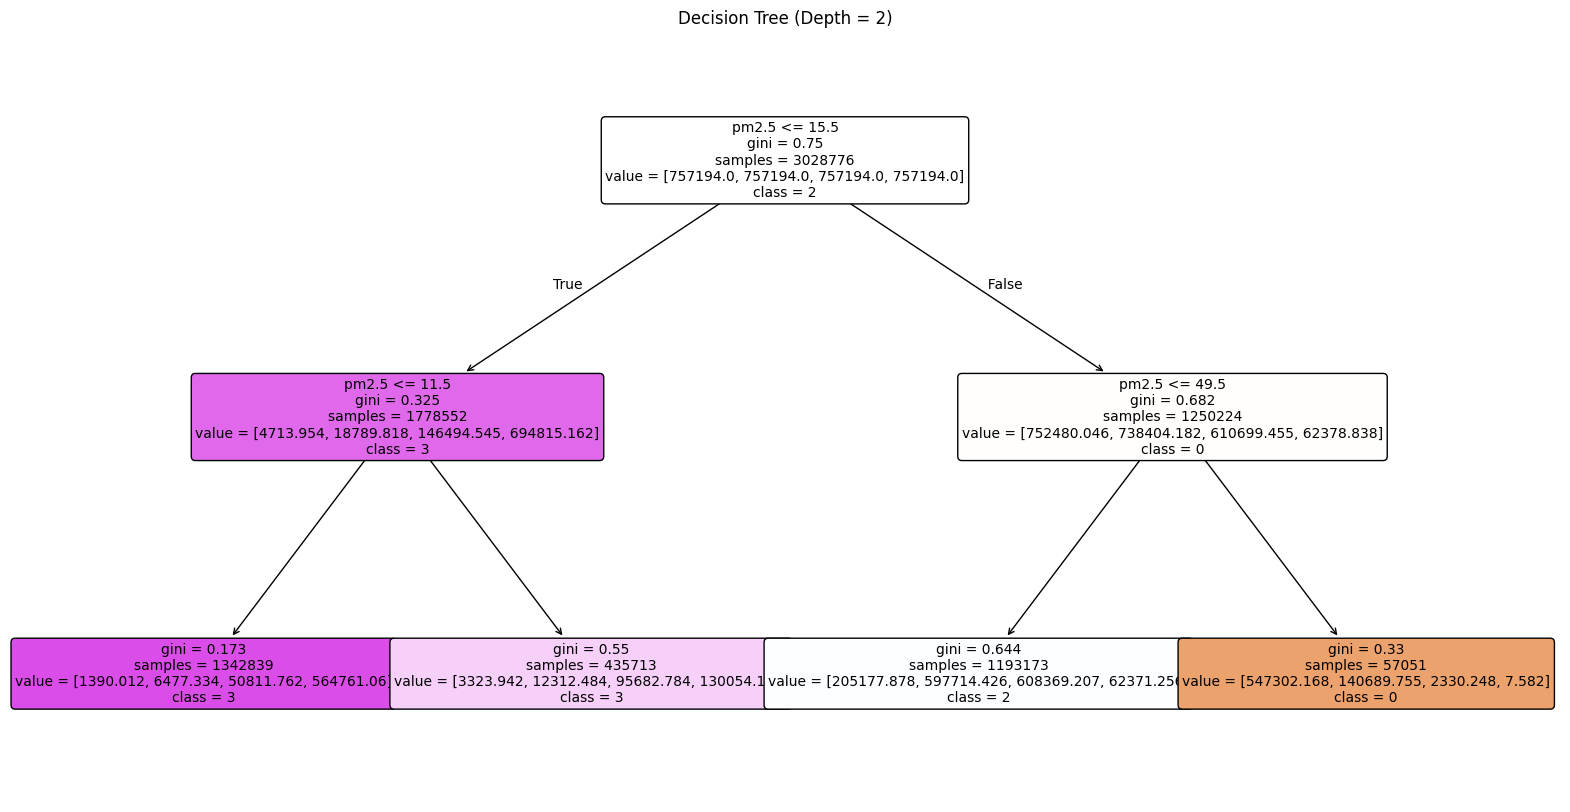

In [ ]:
print("Features used:", X.columns.tolist())
# Modello separato SOLO per disegnare l'albero, su dati NON standardizzati
vis_model = DecisionTreeClassifier(class_weight='balanced',random_state=42,max_depth=2)   # profondità limitata per leggibilità
vis_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    vis_model,
    max_depth=2,
    feature_names=X.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10  # increase the text size in the nodes
)
plt.title("Decision Tree (Depth = 2)")


plt.show()

### **Confusion Matrix:**

The **confusion matrix** shows the model's performance on its predictions.

- The model performs very well on class `5`, and has decent precision on class `4`.


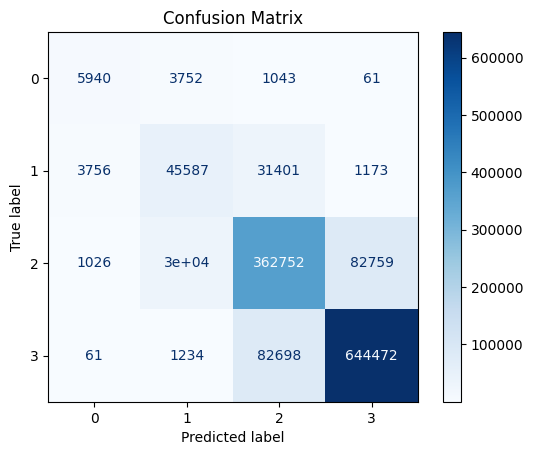

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Setting Parameters for the Analysis
We set:
- a range of tree depths (`max_depth`)
- different values of `test_size` from 0.20 to 0.45 in steps of 0.05



In [ ]:
import numpy as np
min_depth = 2
max_depth = 10
test_sizes = np.array([0.15, 0.20, 0.25, 0.30])
accuracy_list_list = []
size_list = []

## Loop over test_size and Tree Depth
For each combination, we create a new split, normalize the data, and compute the accuracy.



In [ ]:
for test_size in test_sizes:
    size_list.append(test_size)

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # List of accuracies for increasing tree depths
    accuracy_list = []
    for depth in range(min_depth, max_depth):
        model = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_list.append(accuracy)

    accuracy_list_list.append(accuracy_list)

## Plot: Accuracy vs max_depth for different test_size values
We visually compare model performance as tree depth and test set size vary.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

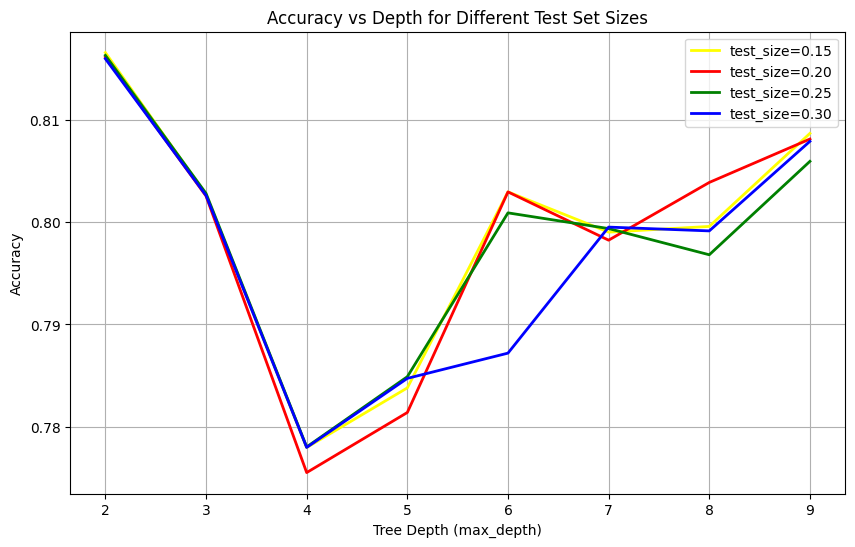

In [ ]:
x_axis = list(range(min_depth, max_depth))
colors = ["yellow", "red", "green", "blue", "black", "brown"]

plt.figure(figsize=(10,6))
for i, acc_list in enumerate(accuracy_list_list):
    plt.plot(x_axis, acc_list, color=colors[i % len(colors)],
             label=f"test_size={size_list[i]:.2f}", linewidth=2)

plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth for Different Test Set Sizes")
plt.legend()
plt.grid(True)
plt.savefig("test.pdf", format="pdf", bbox_inches="tight")
from google.colab import files
files.download("test.pdf")
plt.show()

*Heatmap Comment: max_depth vs test_size*:
- This heatmap shows the average accuracy values obtained for different combinations of `max_depth` (maximum tree depth) and `test_size` (portion of data reserved for testing).
- Accuracy increases quickly up to depth 3, then stabilizes or fluctuates slightly.


### Conclusion:
*Here are some other methods for hyperparameter search in Python:*  
1. `Exhaustive search (Grid Search):` a method where a grid of hyperparameter values is defined to find the optimal combination.  
2. `Random search:` a method where hyperparameter values are selected randomly. This is more efficient than exhaustive search, as it can take a long time when the grid is large or the dataset is big.

